# Meridian Financial: Customer Escalation Intelligence
## Section A: Problem Framing and Responsible AI Planning

### A1. Intended use and prohibited uses

**Intended use:** The model scores each customer by their likelihood of escalating a complaint to the Financial Ombudsman Service (FOS). The Complaints team uses this score only to prioritise proactive outreach, so that at-risk customers are contacted early and their issue is resolved before it escalates.

**Prohibited uses:** The model must NOT be used to:
- refuse, restrict or close a customer's account
- change pricing, credit limits or product offers
- give low-risk customers slower or lower-quality service
- make any decision automatically without human review

### A2. Protected characteristics and proxies

| Column | Could act as a proxy for | Handling decision |
|---|---|---|
| age_band | Age (direct) | **Excluded** from the model. Escalation rates vary only modestly by age (22%–30%), so excluding it costs little accuracy. Retained for bias monitoring in Section E. |
| region | Ethnicity | Included, monitored for disparities in Section E. |
| primary_channel | Age / disability (branch or phone users may be older or less able to use digital channels) | Included, monitored. |
| tenure_months | Age (longer-standing customers tend to be older) | Included, as a genuine indicator of the relationship. |
| account_value_gbp | Wealth / financial vulnerability (Consumer Duty) | Included, monitored. |

### A3. Human-in-the-loop process

1. **Overnight:** the model scores all customers with an open ticket.
2. **By 9am:** High Risk customers appear on the Complaints team's dashboard queue.
3. **Within 1 working day:** a complaints handler reviews the case and the plain-English reason for the flag, and decides whether to act. They can override the model.
4. **Within 2 working days:** if agreed, a senior handler calls the customer to resolve the issue.
5. **Ongoing:** outcomes are logged, and Compliance reviews a sample each quarter, including a bias check.

The model recommends; a person always decides.

### A4. Cost of errors

| Error | Meaning | Cost |
|---|---|---|
| False negative | A customer who escalates was NOT flagged | ~£800 (FOS case handling and compensation) |
| False positive | A customer who would not escalate WAS flagged | ~£25 (staff time for an outreach call) |

Missing an escalation is **32 times** more expensive than an unnecessary call, so the model should lean towards catching more at-risk customers, even at the cost of some extra calls. These figures are used to choose the threshold in Section C.

## Section B: Data Preparation and Exploratory analysis

Load the customer profiles and their outcomes, then join them into one table

In [1]:
import pandas as pd

import numpy as np

customers = pd.read_csv('meridian_customers.csv')
outcomes = pd.read_csv('meridian_outcomes.csv')
print(f'Customers: {customers.shape}, Outcomes: {outcomes.shape}')

df = customers.merge(outcomes, on='customer_id', how='inner')

print(f'shape after merge: {df.shape}')
print(f'Escalation rate: {df["escalated"].mean():.1%}')
df.head()

Customers: (500, 8), Outcomes: (500, 5)
shape after merge: (500, 12)
Escalation rate: 26.8%


,customer_id,age_band,product_type,region,primary_channel,tenure_months,account_value_gbp,previous_complaints,escalated,churned,complaint_count_12m,nps_score
0,CUS-0001,46-55,Personal Loan,North West,App,43,16327,0,False,False,0,30
1,CUS-0002,26-35,Savings Account,Wales,Online,3,16055,1,True,True,0,33
2,CUS-0003,56-65,Savings Account,South East,Phone,4,2004,1,False,False,0,55
3,CUS-0004,26-35,Savings Account,London,App,84,17706,1,True,True,2,16
4,CUS-0005,56-65,Credit Card,Midlands,Online,19,14227,1,False,False,1,25


**Observation:** Both files contain 500 customers, and the merge kept all 500, giving one table with 12 columns. 26.8% of customers (134) escalated their complaint to the Financial Ombudsman.

**Insight:** At roughly £800 per case, those 134 escalations represent around £107,000 in cost in this sample alone. Even a model that helps prevent a fraction of them could save Meridian significant money and protect customer relationships.

In [2]:
print('Missing values per column:')
print(df.isnull().sum())

print(f'\nDuplicate customer IDs: {df["customer_id"].duplicated().sum()}')

df.describe()

Missing values per column:
customer_id            0
age_band               0
product_type           0
region                 0
primary_channel        0
tenure_months          0
account_value_gbp      0
previous_complaints    0
escalated              0
churned                0
complaint_count_12m    0
nps_score              0
dtype: int64

Duplicate customer IDs: 0


,tenure_months,account_value_gbp,previous_complaints,complaint_count_12m,nps_score
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.156000,9916.910000,0.844000,0.930000,45.692000
std,36.217884,13434.387112,0.897371,1.093385,21.777365
min,1.000000,207.000000,0.000000,0.000000,-35.000000
25%,10.000000,2019.750000,0.000000,0.000000,31.000000
50%,24.000000,4887.000000,1.000000,1.000000,47.000000
75%,52.250000,12473.750000,1.000000,2.000000,61.000000
max,250.000000,83513.000000,4.000000,6.000000,100.000000


**Observation:** The data is complete: no missing values and no duplicate customers across all 12 columns. Account values are heavily skewed. The median customer holds £4,887, but the mean is £9,917 because a small number of high-value customers (up to £83,513) pull the average up.

**Insight:** No cleaning is needed before modelling. Because account value is skewed, the median is a better summary of a "typical" customer, and we should keep this in mind when interpreting the model.

In [3]:
prod_esc = df.groupby('product_type')['escalated'].mean().sort_values(ascending=False)

print('Escalation rate by product:')
print((prod_esc * 100).round(1))

Escalation rate by product:
product_type
Personal Loan      36.5
Home Insurance     31.0
Credit Card        29.6
Current Account    24.2
Savings Account    19.3
Mortgage           18.9
Name: escalated, dtype: float64


In [4]:
prod_summary = df.groupby('product_type')['escalated'].agg(['count', 'sum', 'mean'])
prod_summary.columns = ['customers', 'escalated', 'escalation_rate']
prod_summary['escalation_rate'] = (prod_summary['escalation_rate'] * 100).round(1)
prod_summary.sort_values('escalation_rate', ascending=False)

,customers,escalated,escalation_rate
product_type,,,
Personal Loan,85,31,36.5
Home Insurance,71,22,31.0
Credit Card,71,21,29.6
Current Account,153,37,24.2
Savings Account,83,16,19.3
Mortgage,37,7,18.9


**Observation:**
- Personal Loans have the highest escalation rate at 36.5% (31 of 85 customers), followed by Home Insurance at 31.0% (22 of 71). Both are above the overall average of 26.8%.
- Mortgages have the lowest rate at 18.9% (7 of 37). This may reflect the more predictable, heavily regulated nature of the product, but with only 37 customers the rate is less reliable, as a few extra escalations would change it significantly.
- Current Accounts have a below-average rate (24.2%) but produce the most escalations in total (37), because they are the largest customer group (153).

**Insight:** Personal Loan and Home Insurance customers are the highest risk per customer, so complaints on these products should be prioritised for early outreach, and loan charges and insurance claims handling reviewed as likely root causes. Current Accounts deserve attention too: their high volume makes them the biggest single source of Ombudsman cases.

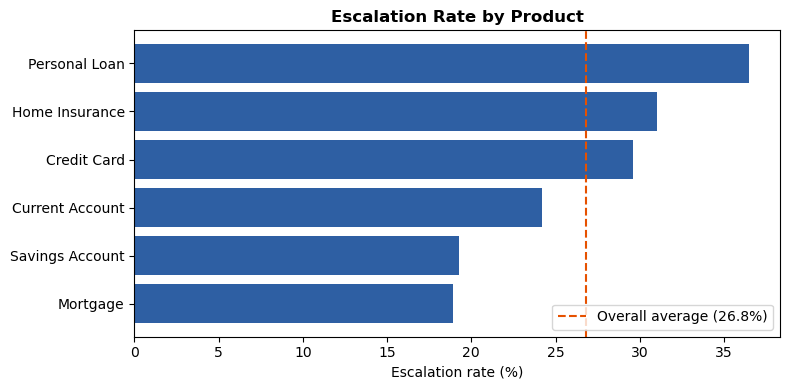

In [5]:
import matplotlib.pyplot as plt

avg = df['escalated'].mean() * 100
plot_data = prod_summary['escalation_rate'].sort_values()


fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(plot_data.index, plot_data.values, color='#2E5FA3')
ax.axvline(avg, color='#E65100', linestyle='--', label=f'Overall average ({avg:.1f}%)')

ax.set_title('Escalation Rate by Product', fontweight='bold')
ax.set_xlabel('Escalation rate (%)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('eda_escalation_by_product.png', dpi=150)
plt.show()




**Chart note:** The chart confirms the table: Personal Loan, Home Insurance and Credit Card sit above the 26.8% average line, while Current Account, Savings and Mortgage sit below it. Saved as `eda_escalation_by_product.png` for the written report and dashboard.

In [6]:
comp_summary = df.groupby('previous_complaints')['escalated'].agg(['count', 'sum', 'mean'])
comp_summary.columns = ['customers', 'escalated', 'escalation_rate']
comp_summary['escalation_rate'] = (comp_summary['escalation_rate'] * 100).round(1)
comp_summary

,customers,escalated,escalation_rate
previous_complaints,,,
0,215,55,25.6
1,174,34,19.5
2,90,37,41.1
3,16,5,31.2
4,5,3,60.0


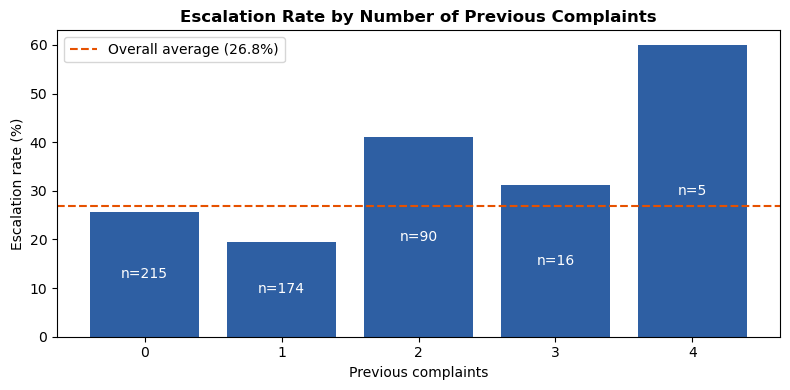

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(comp_summary.index.astype(str), comp_summary['escalation_rate'], color='#2E5FA3')
ax.axhline(avg, color='#E65100', linestyle='--', label=f'Overall average ({avg:.1f}%)')
ax.bar_label(bars, labels=[f'n={n}' for n in comp_summary['customers']], label_type='center', color='white')

ax.set_title('Escalation Rate by Number of Previous Complaints', fontweight='bold')
ax.set_xlabel('Previous complaints')
ax.set_ylabel('Escalation rate (%)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('eda_escalation_by_complaints.png', dpi=150)
plt.show()

In [8]:
df.groupby(df['previous_complaints'] >= 2)['escalated'].agg(['count', 'sum', 'mean'])

,count,sum,mean
previous_complaints,,,
False,389,89,0.228792
True,111,45,0.405405


**Observation:**
- Customers with 0 previous complaints escalate at 25.6% (n=215) and those with 1 at 19.5% (n=174). Combined, the 0–1 group escalates at 22.9%, below the 26.8% average.
- Customers with 2 or more previous complaints escalate at 40.5% combined (45 of 111), almost twice the rate of the 0–1 group. The individual rates for 3 and 4 complaints are based on very small groups (16 and 5 customers), so they were combined with the 2-complaint group for a more reliable figure.
- However, customers with no previous complaints have an average escalation rate (25.6%), but because they are by far the largest group (215 customers), they produce the most escalations (55 of 134, 41%) and the highest estimated cost (around £44,000 at £800 per case).


**Insight:** A second complaint is a clear warning sign: customers raising their second complaint should be flagged for proactive senior outreach. But complaint history alone would miss most escalations, including around £44,000 of cases from customers with no previous complaints. The model in Section C therefore needs to combine several factors to find at-risk customers hidden within that large group.

In [9]:
age_summary = df.groupby('age_band')['escalated'].agg(['count', 'sum', 'mean'])
age_summary.columns = ['customers', 'escalated', 'escalation_rate']
age_summary['escalation_rate'] = (age_summary['escalation_rate'] * 100).round(1)
age_summary

,customers,escalated,escalation_rate
age_band,,,
18-25,62,15,24.2
26-35,123,37,30.1
36-45,113,34,30.1
46-55,92,23,25.0
56-65,64,14,21.9
65+,46,11,23.9


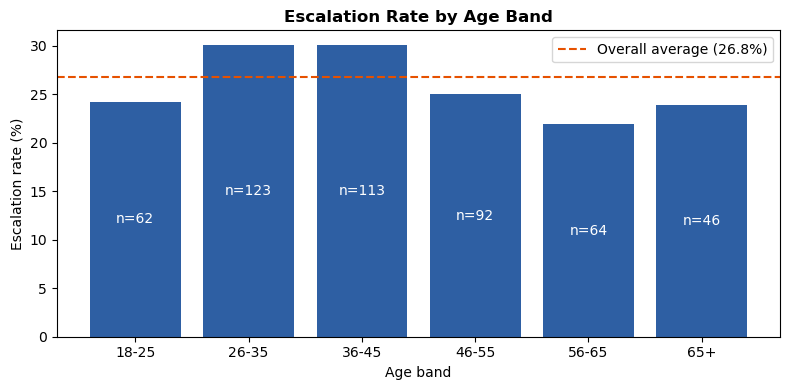

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(age_summary.index.astype(str), age_summary['escalation_rate'], color='#2E5FA3')
ax.axhline(avg, color='#E65100', linestyle='--', label=f'Overall average ({avg:.1f}%)')
ax.bar_label(bars, labels=[f'n={n}' for n in age_summary['customers']], label_type='center', color='white')

ax.set_title('Escalation Rate by Age Band', fontweight='bold')
ax.set_xlabel('Age band')
ax.set_ylabel('Escalation rate (%)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('eda_escalation_by_age.png', dpi=150)
plt.show()

**Observation:**
- Escalation rates vary only modestly by age, from 21.9% (56–65) to 30.1% (26–35 and 36–45). This 8-point spread is much smaller than for product type (18.9%–36.5%) or complaint history (19.5%–41.1%).
- The 26–35 and 36–45 bands account for 71 of 134 escalations (53%), but they are also the two largest groups (236 customers, 47% of the total), so their share of escalations is only slightly above their share of customers.
- The difference may partly reflect product mix (e.g. more loans and credit cards among these ages) rather than age itself.

**Insight:** Age is a protected characteristic, so it must not be used to target or prioritise customers. The modest variation supports the Section A2 decision to exclude `age_band` from the model. Instead, these age-band rates will serve as the baseline for the Section E bias audit, to check that the model does not flag any age group disproportionately.

In [11]:
churn_summary = df.groupby('escalated')['churned'].agg(['count', 'sum', 'mean'])
churn_summary.columns = ['customers', 'churned', 'churn_rate']
churn_summary['churn_rate'] = (churn_summary['churn_rate'] * 100).round(1)
churn_summary

,customers,churned,churn_rate
escalated,,,
False,366,49,13.4
True,134,52,38.8


**Observation:**
- Customers who escalated had a churn rate of 38.8%, almost 3 times the 13.4% rate for customers who did not escalate.
- Escalated customers make up 27% of the customer base (134 of 500) but account for 51% of all churn (52 of 101 customers who left).
- The remaining 49 customers churned without escalating, which may indicate that some customers leave after a poor experience without giving Meridian a formal chance to resolve it.

**Insight:** An escalation costs far more than the ~£800 in case handling: it is strongly associated with losing the customer and their future value across other products. Preventing escalations should therefore also help retention. The 49 "silent" leavers also warrant attention, as the bank may be missing warning signs outside the formal complaints process; the ticket and review text analysed in Section D may help reveal them.

### Section B Summary

**Key findings:**
1. Personal Loans (36.5%) and Home Insurance (31.0%) carry the highest escalation risk per customer, while Current Accounts generate the most escalations in total (37) because of their volume.
2. Customers with 2+ previous complaints escalate at 40.5%, nearly twice the 22.9% of those with 0–1. However, 41% of escalations come from customers with no previous complaints, so complaint history alone would miss most cases.
3. Escalation varies only modestly by age (21.9%–30.1%).
4. Escalated customers had a churn rate of 38.8% versus 13.4% for others, and account for 51% of all customers lost (52 of 101).

**What this means for the model:**
- No single factor identifies at-risk customers on its own, so the model must combine several customer characteristics (product, complaint history, tenure, channel, account value and region).
- `age_band` is excluded because age is a protected characteristic; the modest variation in (3) confirms this costs little accuracy. It is retained only for the Section E bias audit.
- Outcome columns (`churned`, `complaint_count_12m`, `nps_score`) are also excluded, as they are only known after the event and would cause data leakage.

**Overall objective:** move from reacting to escalations to identifying dissatisfaction early, before it becomes an escalation or leads to churn, including the 49 customers who left without ever escalating.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

feature_cols = ['tenure_months', 'account_value_gbp', 'previous_complaints',
                'product_type', 'primary_channel', 'region']
target_col = 'escalated'

df_model = pd.get_dummies(df[feature_cols + [target_col]],
                          columns=['product_type', 'primary_channel', 'region'],
                          drop_first=True)

X = df_model.drop(target_col, axis=1)
y = df_model[target_col].astype(int)

print(f'Features: {X.shape[1]}')
print(f'Target balance: {y.mean():.1%} escalated')
X.head()

Features: 17
Target balance: 26.8% escalated


,tenure_months,account_value_gbp,previous_complaints,product_type_Current Account,product_type_Home Insurance,product_type_Mortgage,product_type_Personal Loan,product_type_Savings Account,primary_channel_Branch,primary_channel_Online,primary_channel_Phone,region_Midlands,region_North East,region_North West,region_Scotland,region_South East,region_Wales
0,43,16327,0,False,False,False,True,False,False,False,False,False,False,True,False,False,False
1,3,16055,1,False,False,False,False,True,False,True,False,False,False,False,False,False,True
2,4,2004,1,False,False,False,False,True,False,False,True,False,False,False,False,True,False
3,84,17706,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,19,14227,1,False,False,False,False,False,False,True,False,True,False,False,False,False,False


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} customers ({y_train.mean():.1%} escalated)')
print(f'Test set:     {X_test.shape[0]} customers ({y_test.mean():.1%} escalated)')

Training set: 400 customers (26.8% escalated)
Test set:     100 customers (27.0% escalated)


In [14]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

for name, model in [('Logistic Regression', lr_model), ('Random Forest', rf_model)]:
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    print(f'\n=== {name} ===')
    print(classification_report(y_test, preds, target_names=['Not Escalated', 'Escalated']))
    print(f'AUC: {roc_auc_score(y_test, proba):.3f}')
    print('Confusion matrix:')
    print(confusion_matrix(y_test, preds))


=== Logistic Regression ===
               precision    recall  f1-score   support

Not Escalated       0.76      0.48      0.59        73
    Escalated       0.30      0.59      0.40        27

     accuracy                           0.51       100
    macro avg       0.53      0.54      0.49       100
 weighted avg       0.64      0.51      0.54       100

AUC: 0.526
Confusion matrix:
[[35 38]
 [11 16]]

=== Random Forest ===
               precision    recall  f1-score   support

Not Escalated       0.73      0.90      0.80        73
    Escalated       0.22      0.07      0.11        27

     accuracy                           0.68       100
    macro avg       0.47      0.49      0.46       100
 weighted avg       0.59      0.68      0.62       100

AUC: 0.561
Confusion matrix:
[[66  7]
 [25  2]]


**Observation:**
- Logistic Regression caught 16 of 27 escalations (recall 0.59), with 38 unnecessary flags.
- Random Forest caught only 2 of 27 (recall 0.07), with 7 unnecessary flags. Its higher accuracy (68% vs 51%) is misleading: it mostly predicts "no escalation", which is right for most customers but misses almost everyone who matters.
- On the test set, Logistic Regression's errors cost about £9,750 (11 missed × £800 + 38 calls × £25), versus £20,175 for Random Forest (25 missed × £800 + 7 calls × £25).
- Both models have an AUC close to 0.5 (LR 0.526, RF 0.561), meaning profile data alone only weakly separates escalators from non-escalators.

**Insight:** Logistic Regression is recommended. Missing an escalation costs 32 times more than an unnecessary call, so catching more at-risk customers matters more than making fewer calls. The extra calls may also reach dissatisfied customers who would otherwise leave without escalating. It is also the more interpretable model, meeting the Compliance requirement for explainable decisions (Section A). However, its predictive power is weak, so it should support, not replace, staff judgement, and adding text signals from Section D is likely to be needed for a reliable model.

In [15]:
chosen_model = lr_model
y_proba = chosen_model.predict_proba(X_test_scaled)[:, 1]

COST_FN = 800
COST_FP = 25

print(f"{'Threshold':<12}{'Caught':<8}{'Calls':<8}{'Missed':<8}{'Recall':<8}{'Est Cost (500 customers)'}")
print('-' * 70)

for thresh in [0.30, 0.40, 0.50]:
    y_pred = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn)
    total_cost = (fn * COST_FN + fp * COST_FP) * 5
    print(f'{thresh:<12}{tp:<8}{fp:<8}{fn:<8}{recall:<8.2f}£{total_cost:,.0f}')

Threshold   Caught  Calls   Missed  Recall  Est Cost (500 customers)
----------------------------------------------------------------------
0.3         25      69      2       0.93    £16,625
0.4         21      54      6       0.78    £30,750
0.5         16      38      11      0.59    £48,750


**Observation:**
- Lowering the threshold from 0.50 to 0.30 increases escalations caught from 16 to 25 of 27 (recall 0.59 → 0.93), at the cost of more unnecessary calls (38 → 69).
- Because a missed escalation (£800) costs 32 times more than an unnecessary call (£25), the estimated cost falls from £48,750 at 0.50 to £16,625 at 0.30, a saving of about £32,000 across 500 customers.
- However, at 0.30 the model flags 94 of 100 test customers. Simply contacting every customer with an open complaint would cost less (about £9,125), showing that the model does not yet outperform a simple rule.

**Recommendation:** Of the thresholds tested, 0.30 is recommended as it minimises cost under the Section A figures (£800 per missed escalation, £25 per call). However, the model is not yet strong enough to justify deployment on profile data alone. Adding signals from customer text (Section D) should be tested before the model is used to prioritise outreach.

## Section E: Responsible AI – Bias Audit and Fairness Assessment

We check whether the Logistic Regression model performs differently for different customer groups, particularly by age band (a protected characteristic excluded from the model) and product type. The audit uses the model's default 0.50 threshold, as at 0.30 almost all customers are flagged.

In [16]:
test_idx = X_test.index
df_test = df.loc[test_idx].copy()
df_test['y_pred'] = chosen_model.predict(X_test_scaled)
df_test['y_proba'] = chosen_model.predict_proba(X_test_scaled)[:, 1]
df_test['y_true'] = y_test.values

df_test[['customer_id', 'age_band', 'product_type', 'y_true', 'y_pred', 'y_proba']].head()

,customer_id,age_band,product_type,y_true,y_pred,y_proba
206,CUS-0207,56-65,Credit Card,0,1,0.608162
132,CUS-0133,26-35,Credit Card,0,1,0.508447
425,CUS-0426,26-35,Mortgage,0,1,0.595312
455,CUS-0456,46-55,Mortgage,0,1,0.554225
69,CUS-0070,56-65,Home Insurance,0,0,0.459088


In [17]:
df_test['correct'] = (df_test['y_true'] == df_test['y_pred']).astype(int)
df_test['caught'] = ((df_test['y_true'] == 1) & (df_test['y_pred'] == 1)).astype(int)
df_test['false_alarm'] = ((df_test['y_true'] == 0) & (df_test['y_pred'] == 1)).astype(int)

age_audit = df_test.groupby('age_band').agg(
    customers=('y_true', 'count'),
    escalated=('y_true', 'sum'),
    flagged=('y_pred', 'sum'),
    caught=('caught', 'sum'),
    false_alarms=('false_alarm', 'sum'),
    accuracy=('correct', 'mean'))

age_audit['recall'] = (age_audit['caught'] / age_audit['escalated']).round(2)
age_audit['false_positive_rate'] = (age_audit['false_alarms'] / (age_audit['customers'] - age_audit['escalated'])).round(2)
age_audit['accuracy'] = age_audit['accuracy'].round(2)
age_audit

,customers,escalated,flagged,caught,false_alarms,accuracy,recall,false_positive_rate
age_band,,,,,,,,
18-25,14,4,6,2,4,0.57,0.50,0.40
26-35,21,5,11,3,8,0.52,0.60,0.50
36-45,22,9,11,4,7,0.45,0.44,0.54
46-55,23,5,15,4,11,0.48,0.80,0.61
56-65,12,1,8,1,7,0.42,1.00,0.64
65+,8,3,3,2,1,0.75,0.67,0.20


**Highest false positive rate:** The 56–65 group has the highest false positive rate (0.64), yet only 1 of 12 customers (8%) actually escalated, the lowest real rate of any group. This is not proportionate. The 46–55 group shows a similar pattern (FPR 0.61, with 5 of 23 escalating). As age is not a model input, the model may be picking up age indirectly through proxy features such as channel or tenure, a risk identified in Section A2. Because a flag only leads to a courtesy call (Section A1), the direct harm is limited, but it still represents unequal treatment by a protected characteristic under the Equality Act 2010.

**Lowest recall:** The 36–45 group has the lowest recall (0.44). The model misses more than half of the real escalators in the group with the highest number of actual escalations (9 of 22), so the customers who most need help are the most likely to be missed.

**Deployment recommendation:** The model should not be deployed as-is. Group sizes are small (8–23 customers), so these rates are unstable, but they are clear warning signs. If used at all, it should only be with conditions:
- every flag is reviewed by a complaints handler before any contact (Section A3);
- false positive rate and recall are monitored by age band every quarter;
- the audit is repeated on a much larger sample before any wider use;
- the features driving over-flagging of older customers are investigated (Section F, SHAP).

Note: this audit uses the default 0.50 threshold; at 0.30, almost all customers are flagged regardless of group.

In [18]:
# Section E (extra): audit at the recommended 0.30 threshold
df_test['y_pred_030'] = (df_test['y_proba'] >= 0.30).astype(int)

df_test['caught_030']      = ((df_test['y_pred_030'] == 1) & (df_test['y_true'] == 1)).astype(int)
df_test['false_alarm_030'] = ((df_test['y_pred_030'] == 1) & (df_test['y_true'] == 0)).astype(int)
df_test['not_escalated']   = (df_test['y_true'] == 0).astype(int)

age_audit_030 = df_test.groupby('age_band').agg(
    customers=('y_true', 'count'),
    escalated=('y_true', 'sum'),
    not_escalated=('not_escalated', 'sum'),
    caught=('caught_030', 'sum'),
    false_alarms=('false_alarm_030', 'sum')
)
age_audit_030['recall'] = (age_audit_030['caught'] / age_audit_030['escalated']).round(2)
age_audit_030['false_positive_rate'] = (age_audit_030['false_alarms'] / age_audit_030['not_escalated']).round(2)
age_audit_030

,customers,escalated,not_escalated,caught,false_alarms,recall,false_positive_rate
age_band,,,,,,,
18-25,14,4,10,4,9,1.0,0.90
26-35,21,5,16,3,15,0.6,0.94
36-45,22,9,13,9,12,1.0,0.92
46-55,23,5,18,5,17,1.0,0.94
56-65,12,1,11,1,11,1.0,1.00
65+,8,3,5,3,5,1.0,1.00


**Observation: Audit at the recommended 0.30 threshold**
The Section E audit above used the model's default 0.50 threshold. At the 0.30 threshold recommended
in Section C, the model flags 94 of 100 customers. Recall rises to 1.0 for every age group except
26–35 (0.6, 2 of 5 escalations missed), and false positive rates become almost identical (0.90–1.00).
The model appears fairer, but only because it is flagging nearly everyone, not because it is
distinguishing risk better. At this threshold it performs like a "contact every customer" policy,
which Section C showed is cheaper. This reinforces the conclusion that the model is not ready to deploy.

In [19]:
df_test['correct'] = (df_test['y_true'] == df_test['y_pred']).astype(int)
df_test['caught'] = ((df_test['y_true'] == 1) & (df_test['y_pred'] == 1)).astype(int)
df_test['false_alarm'] = ((df_test['y_true'] == 0) & (df_test['y_pred'] == 1)).astype(int)

product_audit = df_test.groupby('product_type').agg(
    customers=('y_true', 'count'),
    escalated=('y_true', 'sum'),
    flagged=('y_pred', 'sum'),
    caught=('caught', 'sum'),
    false_alarms=('false_alarm', 'sum'),
    accuracy=('correct', 'mean'))

product_audit['recall'] = (product_audit['caught'] / product_audit['escalated']).round(2)
product_audit['false_positive_rate'] = (product_audit['false_alarms'] / (product_audit['customers'] - product_audit['escalated'])).round(2)
product_audit['accuracy'] = product_audit['accuracy'].round(2)
product_audit

,customers,escalated,flagged,caught,false_alarms,accuracy,recall,false_positive_rate
product_type,,,,,,,,
Credit Card,15,5,9,3,6,0.47,0.60,0.60
Current Account,30,7,17,6,11,0.60,0.86,0.48
Home Insurance,12,4,6,3,3,0.67,0.75,0.38
Mortgage,8,0,4,0,4,0.50,NaN,0.50
Personal Loan,16,5,15,4,11,0.25,0.80,1.00
Savings Account,19,6,3,0,3,0.53,0.00,0.23


**Highest false positive rate:** Personal Loans have the highest false positive rate (1.00): all 11 loan customers who did not escalate were still flagged, and 15 of 16 loan customers were flagged overall. Credit Cards are second (0.60). This mirrors Section B, where Personal Loans had the highest escalation rate (36.5%): the model appears to treat almost every loan customer as high risk because of their product, rather than anything about the individual.

**Lowest recall:** Savings Accounts have the lowest recall (0.00). All 6 real escalators were missed, while the 3 savings customers who were flagged did not escalate. Savers had a low escalation rate in Section B (19.3%), so the model has learned to treat them as low risk, meaning dissatisfied savers are systematically overlooked.

**Mortgage:** No mortgage customers in the test set escalated, so recall cannot be calculated (0 ÷ 0, shown as NaN). This reflects the absence of positive cases, not model performance.

**Conclusion:** The model is largely reproducing product-level averages rather than identifying individual risk. Product type is not a protected characteristic, but systematically missing savers who need help is a Consumer Duty concern. Combined with the age-band findings, the model is not ready for deployment. If used at all, every flag should be reviewed by a complaints handler (Section A3), and the model should be retrained with stronger individual-level signals, such as the customer text analysed in Section D, and re-audited on a larger sample.

## Section F: Explainability (FCA Consumer Duty Requirement)

Following the Head of Compliance's request, we add an explainability layer using SHAP (SHapley Additive exPlanations). SHAP breaks each customer's risk score into the contribution of each feature, so any flag can be explained in plain English.

Background dataset has 400 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=400 when initializing the masker.


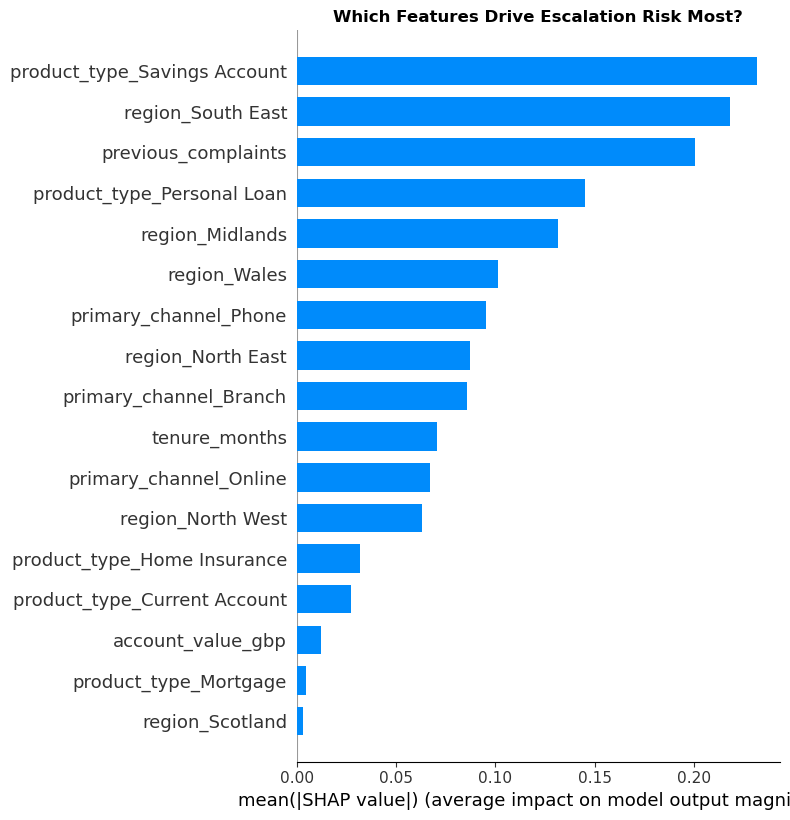

In [20]:
import shap

explainer = shap.LinearExplainer(chosen_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=X.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('Which Features Drive Escalation Risk Most?', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150)
plt.show()

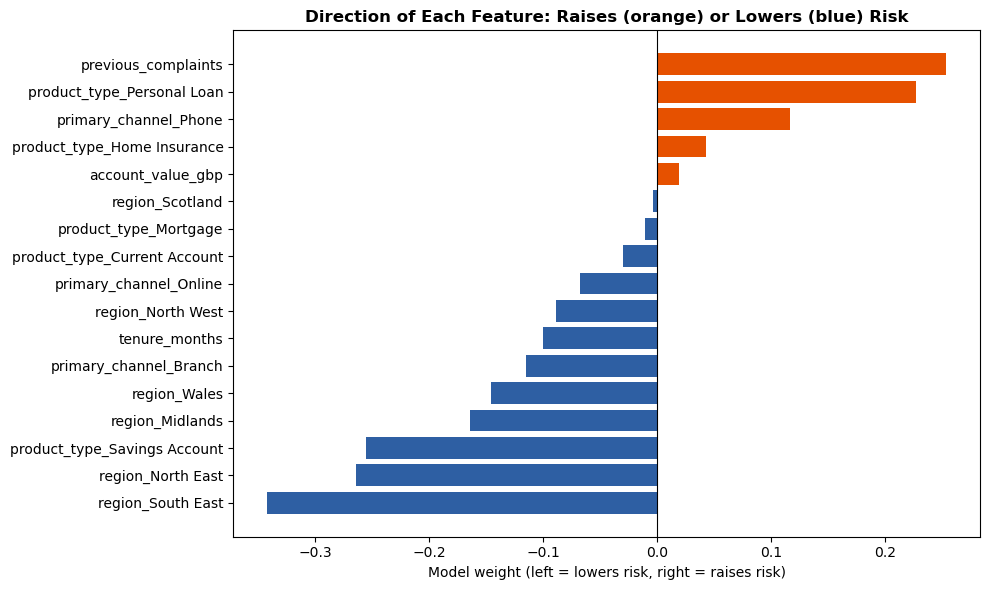

In [21]:
weights = pd.Series(chosen_model.coef_[0], index=X.columns).sort_values()
colours = ['#E65100' if w > 0 else '#2E5FA3' for w in weights]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(weights.index, weights.values, color=colours)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_title('Direction of Each Feature: Raises (orange) or Lowers (blue) Risk', fontweight='bold')
ax.set_xlabel('Model weight (left = lowers risk, right = raises risk)')

plt.tight_layout()
plt.savefig('feature_direction.png', dpi=150)
plt.show()

**Observation:**
- The most influential features are Savings Account, South East region, previous complaints and Personal Loan. Previous complaints and Personal Loan push risk up; Savings Account and South East push risk down.
- This explains the Section E findings. The model assumes Personal Loan customers are high risk, which is why it flagged 15 of 16 of them, and assumes savers are low risk, which is why it missed all 6 savers who escalated.
- Region is the second most influential feature, and four regions appear in the top eight. Customers in the South East are treated as lower risk simply because of where they live.

**Insight:** The model is largely stereotyping customers by product and location rather than judging individual behaviour. Previous complaints is the only strong individual-level signal. Region was identified in Section A2 as a possible proxy for ethnicity, since communities often live in the same areas, so heavy reliance on it creates a risk of indirect ethnic bias. Channel (Phone, Branch), flagged in A2 as a possible age proxy, may also explain the over-flagging of older customers found in Section E. Before any deployment, removing or reviewing region as a model input should be considered.

Customer details:
customer_id                 CUS-0185
age_band                       26-35
product_type           Personal Loan
primary_channel                  App
region                        London
tenure_months                     27
previous_complaints                2
account_value_gbp              10578
Name: 184, dtype: object

Risk score: 79%
Actually escalated: Yes


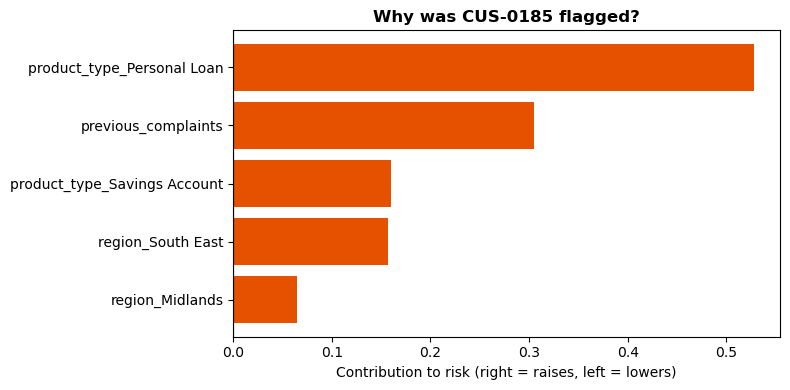

In [22]:
pos = df_test['y_proba'].values.argmax()
customer = df_test.iloc[pos]

print('Customer details:')
print(customer[['customer_id', 'age_band', 'product_type', 'primary_channel', 'region',
                'tenure_months', 'previous_complaints', 'account_value_gbp']])
print(f"\nRisk score: {customer['y_proba']:.0%}")
print(f"Actually escalated: {'Yes' if customer['y_true'] == 1 else 'No'}")

contrib = pd.Series(shap_values[pos], index=X.columns)
top5 = contrib.sort_values(key=abs, ascending=False).head(5).sort_values()

colours = ['#E65100' if v > 0 else '#2E5FA3' for v in top5]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top5.index, top5.values, color=colours)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f"Why was {customer['customer_id']} flagged?", fontweight='bold')
ax.set_xlabel('Contribution to risk (right = raises, left = lowers)')
plt.tight_layout()
plt.savefig('shap_individual.png', dpi=150)
plt.show()

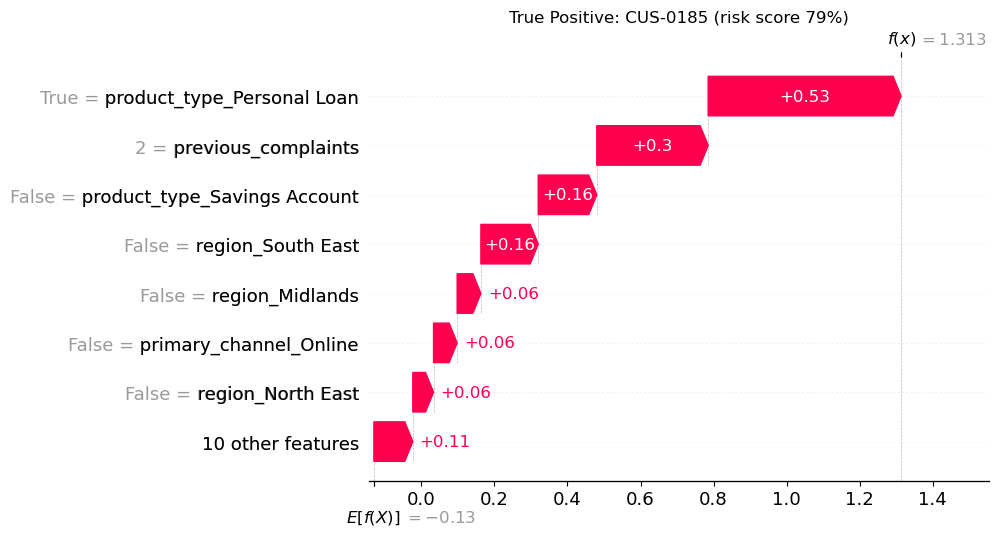

customer_id                 CUS-0185
product_type           Personal Loan
region                        London
primary_channel                  App
tenure_months                     27
previous_complaints                2
y_true                             1
Name: 184, dtype: object 



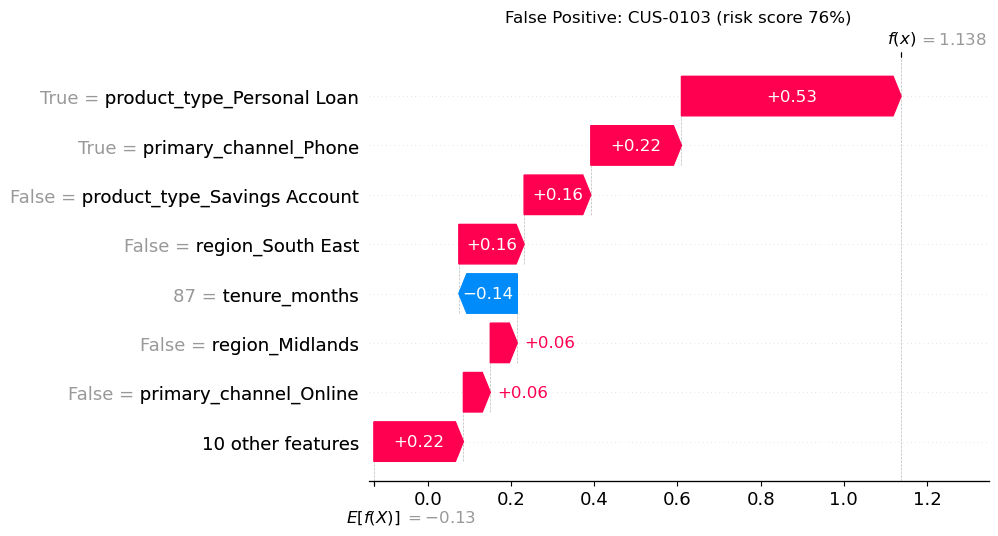

customer_id                 CUS-0103
product_type           Personal Loan
region                        London
primary_channel                Phone
tenure_months                     87
previous_complaints                1
y_true                             0
Name: 102, dtype: object 



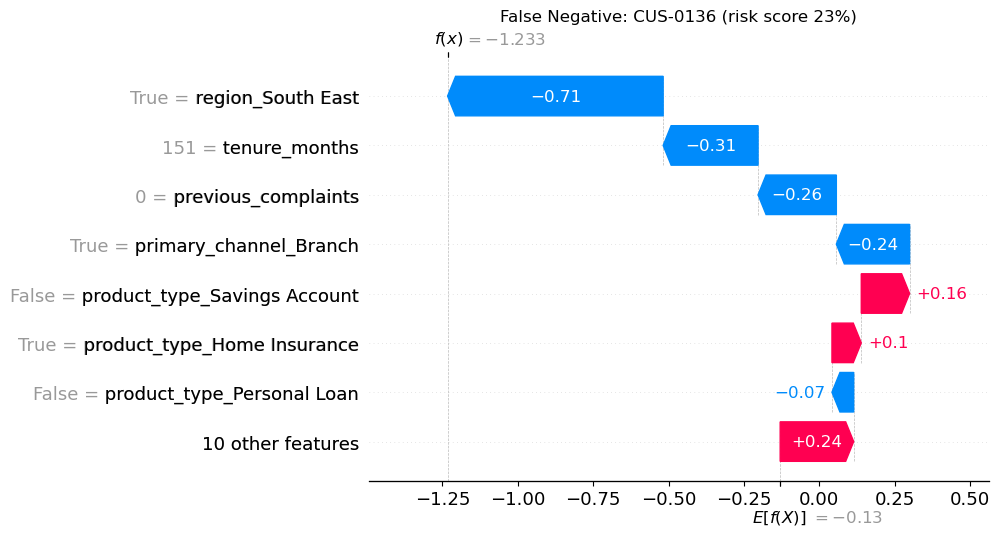

customer_id                  CUS-0136
product_type           Home Insurance
region                     South East
primary_channel                Branch
tenure_months                     151
previous_complaints                 0
y_true                              1
Name: 135, dtype: object 



In [23]:
# Section F (extra): waterfall explanations for one TP, one FP and one FN at the 0.30 threshold
threshold = 0.30
proba = df_test['y_proba'].values
true  = df_test['y_true'].values
pred  = (proba >= threshold).astype(int)

tp = np.where((true == 1) & (pred == 1))[0]   # flagged and escalated
fp = np.where((true == 0) & (pred == 1))[0]   # flagged but did not escalate
fn = np.where((true == 1) & (pred == 0))[0]   # escalated but missed

cases = {
    'True Positive':  tp[proba[tp].argmax()],   # most confident correct flag
    'False Positive': fp[proba[fp].argmax()],   # most confident wrong flag
    'False Negative': fn[proba[fn].argmin()],   # most confidently missed
}

base = np.atleast_1d(explainer.expected_value)[0]

for label, pos in cases.items():
    cust = df_test.iloc[pos]
    exp = shap.Explanation(
        values=shap_values[pos],
        base_values=base,
        data=X_test.iloc[pos].values,          # original (unscaled) values, easier to read
        feature_names=X.columns.tolist()
    )
    shap.plots.waterfall(exp, max_display=8, show=False)
    plt.title(f"{label}: {cust['customer_id']} (risk score {cust['y_proba']:.0%})")
    plt.savefig(f"shap_waterfall_{label.lower().replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(cust[['customer_id', 'product_type', 'region', 'primary_channel',
                'tenure_months', 'previous_complaints', 'y_true']], '\n')

**False Positive – CUS-0103 (risk score 76%, did not escalate)**

The three factors that contributed most to this customer being flagged were holding a Personal Loan
(the strongest single push towards higher risk), contacting Meridian by phone (the second largest
increase), and not holding a savings account. Their long relationship with Meridian (87 months)
reduced their risk, but not enough to offset these factors. The model assigned this customer a risk
score of 76%, compared to the average of 50%. This assessment led to a proactive outreach call,
but the customer did not escalate, so the call was unnecessary (cost: £25).

Note: the customer was flagged for their product and contact channel, not for their behaviour (only
1 previous complaint). Phone contact may act as a proxy for age, which should be monitored.

**False Negative – CUS-0136 (risk score 23%, did escalate)**

The three factors that contributed most to this customer NOT being flagged were living in the South
East (by far the largest reduction in risk), their long relationship with Meridian (151 months),
and having no previous complaints. Holding Home Insurance slightly increased their risk. The model
assigned this customer a risk score of 23%, compared to the average of 50%. This assessment did not
lead to a proactive outreach action, and the customer went on to escalate (cost: £800).

Note: the customer's region outweighed every other factor combined. A customer was missed largely
because of where they live, which is direct evidence of the region-as-proxy risk identified in
Section F and on the Compliance page.

**Plain-English explanation for CUS-0185 (risk score 79%):**

This customer was flagged mainly because they hold a Personal Loan, the product most associated with escalation. A second factor was their complaint history: they had raised 2 previous complaints, the level at which escalation risk roughly doubles (Section B). Smaller factors were that they do not hold a savings account and do not live in a region the model treats as lower risk.

The model assigned this customer a risk score of 79%, compared to the average of 50%. This assessment led to a proactive outreach call. This customer did escalate, so the flag was a correct call.

**Reflection:** The two main reasons (their product and their complaint history) are fair and easy to explain to a customer or regulator. However, part of the score came from where they live. Region may act as a proxy for ethnicity (Section A2), so "you were flagged partly because of where you live" would not be an acceptable explanation under Consumer Duty. This supports removing region from the model.

### Section F Summary

SHAP makes every flag explainable in plain English, meeting the Head of Compliance's requirement. Globally, the model relies most on product type, region and previous complaints. Individual explanations such as CUS-0185 show that when a flag is driven by complaint history and product, it is fair and easy to justify. However, the heavy weight given to region, and the influence of channel, raise fairness concerns that match the Section E bias audit. Recommended changes before deployment: remove region as an input, review channel, and add individual-level signals such as complaint text (Section D).

## Section D: NLP – Understanding What Customers Are Actually Saying (Azure AI Language)

The ML model tells us who is at risk; the text tells us why. We use Azure AI Language (Free F0 tier, UK South region) to score the sentiment of 919 support tickets and 310 reviews, and to extract key phrases. The API key is entered at runtime with getpass and is never stored in this notebook.

*Note: Section D was completed after Section F; all cells run top to bottom.*

In [24]:
from getpass import getpass
from azure.ai.textanalytics import TextAnalyticsClient
from azure.core.credentials import AzureKeyCredential

ENDPOINT = 'https://meridian-language-raphael.cognitiveservices.azure.com/'
KEY = getpass('Paste your Azure key and press Enter: ')

client = TextAnalyticsClient(endpoint=ENDPOINT, credential=AzureKeyCredential(KEY))

test_docs = ['The staff were brilliant and fixed my problem quickly.',
             'I have been waiting three weeks and nobody has called me back.',
             'I would like to update my address.']

for doc in client.analyze_sentiment(documents=test_docs):
    print(doc.sentiment, '| positive:', doc.confidence_scores.positive,
          '| negative:', doc.confidence_scores.negative)

Paste your Azure key and press Enter:  ········


positive | positive: 1.0 | negative: 0.0
negative | positive: 0.0 | negative: 1.0
neutral | positive: 0.17 | negative: 0.08


In [25]:
tickets = pd.read_csv('meridian_tickets.csv')

print('Total tickets:', len(tickets))
print('Different texts:', tickets['ticket_text'].nunique())

Total tickets: 919
Different texts: 117


In [26]:
tickets['ticket_text'].value_counts().head(10)

ticket_text
There is an unexplained charge of £45 on my account from last Tuesday.              39
I was charged twice for the same transaction and need this refunded immediately.    39
I want to understand what interest rate applies to my savings account.              39
My account has been locked and I need it unlocked as soon as possible.              36
I cannot log into my online account and the reset link is not working.              36
I have been waiting three weeks for a billing dispute to be resolved.               35
What is the process for increasing my credit limit?                                 34
I need to know what the excess is on my home insurance policy.                      33
Can you explain the early repayment charge on my loan?                              32
There are multiple small transactions I did not authorise on my account.            30
Name: count, dtype: int64

In [27]:
import time

tickets = pd.read_csv('meridian_tickets.csv')
unique_texts = tickets['ticket_text'].unique().tolist()
print(f'Tickets: {len(tickets)}, unique texts sent to Azure: {len(unique_texts)}')

rows = []
for i in range(0, len(unique_texts), 10):
    batch = unique_texts[i:i + 10]
    results = client.analyze_sentiment(documents=batch)
    for text, doc in zip(batch, results):
        if not doc.is_error:
            rows.append({'ticket_text': text,
                         'sentiment': doc.sentiment,
                         'positive_score': doc.confidence_scores.positive,
                         'neutral_score': doc.confidence_scores.neutral,
                         'negative_score': doc.confidence_scores.negative})
    time.sleep(1)

sentiment_lookup = pd.DataFrame(rows)
sentiment_lookup.to_csv('ticket_sentiment_lookup.csv', index=False)

tickets = tickets.merge(sentiment_lookup, on='ticket_text', how='left')
print(tickets['sentiment'].value_counts())

Tickets: 919, unique texts sent to Azure: 117
sentiment
negative    628
neutral     269
positive     17
mixed         5
Name: count, dtype: int64


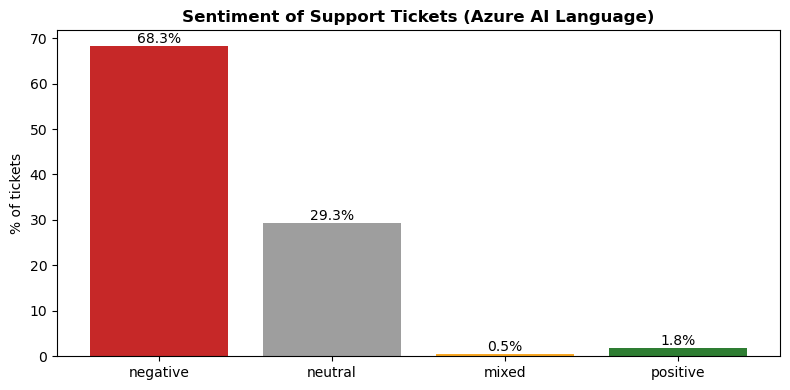

In [28]:
order = ['negative', 'neutral', 'mixed', 'positive']
sent_pct = (tickets['sentiment'].value_counts(normalize=True) * 100).reindex(order).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(sent_pct.index, sent_pct.values,
              color=['#C62828', '#9E9E9E', '#F9A825', '#2E7D32'])
ax.bar_label(bars, labels=[f'{v}%' for v in sent_pct.values])

ax.set_title('Sentiment of Support Tickets (Azure AI Language)', fontweight='bold')
ax.set_ylabel('% of tickets')

plt.tight_layout()
plt.savefig('nlp_sentiment_distribution.png', dpi=150)
plt.show()

**Observation:** 68.3% of support tickets are negative, 29.3% neutral and only 1.8% positive (0.5% mixed).

**Insight:** Most customers contact Meridian already frustrated. As tickets are written before support responds, this negativity mainly reflects the underlying problems (e.g. unexplained charges, duplicate transactions, account lockouts) rather than how support handled them. Reducing these root causes, alongside faster, more empathetic complaint handling, could lower negative contact volumes. Whether negative ticket sentiment is linked to escalation is tested below.

In [29]:
cat_sent = tickets.groupby('category').agg(
    tickets=('ticket_id', 'count'),
    avg_negative=('negative_score', 'mean'),
    pct_negative=('sentiment', lambda s: (s == 'negative').mean() * 100)
).round(2).sort_values('avg_negative', ascending=False)

cat_sent

,tickets,avg_negative,pct_negative
category,,,
Service Failure,96,0.99,100.00
Billing,180,0.91,100.00
Refund Request,48,0.90,100.00
Complaint,124,0.86,82.26
Account Access,165,0.79,63.03
Fraud Query,115,0.61,64.35
Product Query,191,0.19,12.57


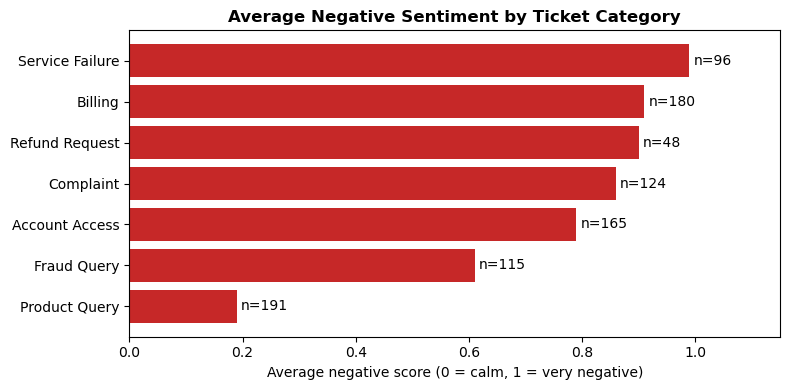

In [30]:
plot_cat = cat_sent.sort_values('avg_negative')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(plot_cat.index, plot_cat['avg_negative'], color='#C62828')
ax.bar_label(bars, labels=[f'n={n}' for n in plot_cat['tickets']], padding=3)

ax.set_title('Average Negative Sentiment by Ticket Category', fontweight='bold')
ax.set_xlabel('Average negative score (0 = calm, 1 = very negative)')
ax.set_xlim(0, 1.15)

plt.tight_layout()
plt.savefig('nlp_sentiment_by_category.png', dpi=150)
plt.show()

**Observation:**
- Service Failure generates the most negative sentiment (average negative score 0.99, with 100% of its 96 tickets negative).
- Product Query is the highest-volume category (191 tickets) but the least negative (13% negative), as these are mostly routine questions about rates, charges and policy terms.
- Billing combines both: the second-highest volume (180 tickets) and 100% negative, making it the largest single source of negative contact.

**Insight:** The most negative category is not the busiest. Meridian should prioritise service reliability (Service Failure) and billing accuracy (unexplained and duplicate charges), which together account for 276 entirely negative tickets. The high volume of Product Queries could also be reduced by giving customers clearer explanations of rates, charges and policy terms at the point of sale.

Customers: 500
           count   mean  median
escalated                      
False        366  0.701   0.812
True         134  0.737   0.917


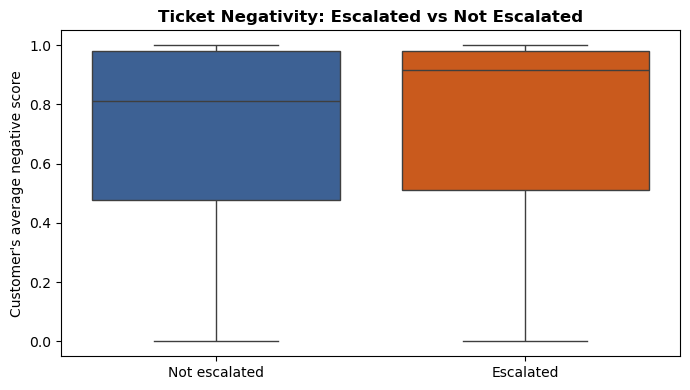

In [31]:
import seaborn as sns

cust_sent = tickets.groupby('customer_id').agg(
    num_tickets=('ticket_id', 'count'),
    avg_negative=('negative_score', 'mean')
).reset_index()

cust_sent = cust_sent.merge(outcomes, on='customer_id', how='inner')
print(f'Customers: {len(cust_sent)}')
print(cust_sent.groupby('escalated')['avg_negative'].agg(['count', 'mean', 'median']).round(3))

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=cust_sent, x='escalated', y='avg_negative',
            hue='escalated', palette=['#2E5FA3', '#E65100'], legend=False, ax=ax)
ax.set_xticks([0, 1], ['Not escalated', 'Escalated'])
ax.set_title('Ticket Negativity: Escalated vs Not Escalated', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel("Customer's average negative score")
plt.tight_layout()
plt.savefig('nlp_sentiment_vs_escalation.png', dpi=150)
plt.show()

**Observation:** Customers who escalated wrote slightly more negative tickets than those who did not (average negative score 0.737 vs 0.701, a difference of 0.036; medians 0.917 vs 0.812). However, the two distributions overlap almost completely: most customers write negative tickets whether or not they escalate.

**Insight:** Ticket sentiment only weakly predicts escalation, so on its own it is unlikely to fix the weak performance of the profile-based model (Section C), which remains close to a coin toss and not ready for deployment. A key limitation is that the ticket texts are highly standardised (117 unique texts across 919 tickets), so sentiment largely reflects the ticket category rather than each customer's own words. Real, free-text complaints would likely carry a stronger individual signal and should be tested before any deployment decision.

In [32]:
from collections import Counter

phrase_rows = []
for i in range(0, len(unique_texts), 10):
    batch = unique_texts[i:i + 10]
    results = client.extract_key_phrases(documents=batch)
    for text, doc in zip(batch, results):
        if not doc.is_error:
            phrase_rows.append({'ticket_text': text, 'key_phrases': doc.key_phrases})
    time.sleep(1)

phrase_lookup = pd.DataFrame(phrase_rows)
tickets_kp = tickets.merge(phrase_lookup, on='ticket_text', how='left')

all_phrases = [p.lower() for phrases in tickets_kp['key_phrases'].dropna() for p in phrases]
top_phrases = pd.DataFrame(Counter(all_phrases).most_common(20), columns=['phrase', 'count'])

top_phrases

,phrase,count
0,account,207
1,issue,47
2,unexplained charge,43
3,last tuesday,43
4,same transaction,42
5,interest rate,41
6,savings account,41
7,credit limit,40
8,process,40
9,online account,40


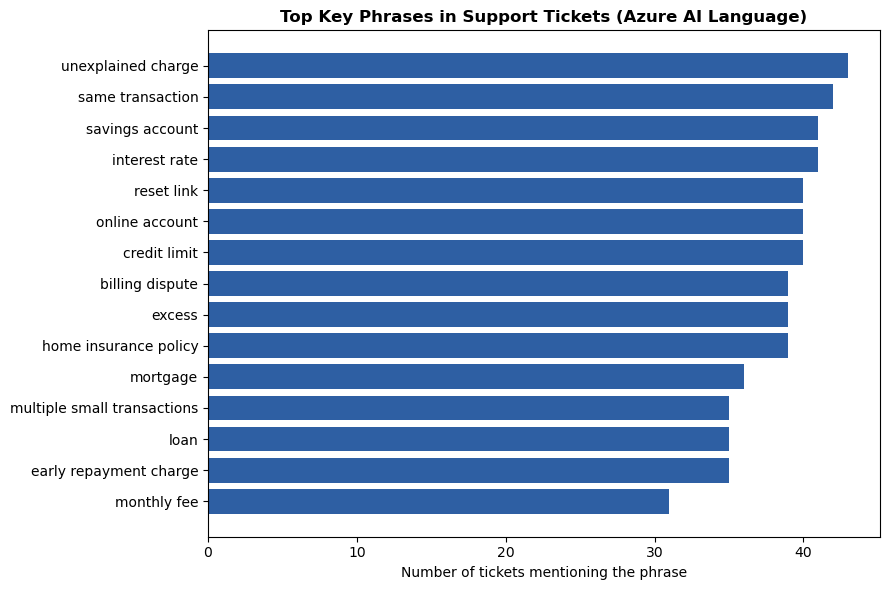

In [33]:
noise = ['account', 'issue', 'process', 'terms', 'last tuesday']
clean_phrases = top_phrases[~top_phrases['phrase'].isin(noise)].head(15).sort_values('count')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(clean_phrases['phrase'], clean_phrases['count'], color='#2E5FA3')

ax.set_title('Top Key Phrases in Support Tickets (Azure AI Language)', fontweight='bold')
ax.set_xlabel('Number of tickets mentioning the phrase')

plt.tight_layout()
plt.savefig('nlp_key_phrases.png', dpi=150)
plt.show()

**Observation: Key phrases**
- The top phrases match what the Head of Customer Experience would expect. **Charges and billing** dominate
  (unexplained charge, same transaction, billing dispute, multiple small transactions, monthly fee),
  followed by **login/access problems** (reset link, online account).
- **Surprise 1: Loans.** Personal Loan had the highest escalation rate in Section B, yet "loan" and
  "early repayment charge" rank low here. Loan customers may raise fewer tickets, but the tickets
  they do raise are high stakes and more likely to escalate.
- **Surprise 2: Savings.** "Savings account" and "interest rate" are among the most common phrases,
  yet the model in Section E missed every saver who escalated. Savers are talking about problems,
  and the model is not listening to them.
- Generic phrases (account, issue, process, terms, last tuesday) were removed by hand. The AI
  extracts phrases, but a human still has to judge which ones mean something.

In [34]:
reviews = pd.read_csv('meridian_reviews.csv')

# Turn the text dates into real dates
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

# Label each review with its month, e.g. 2025-06
reviews['month'] = reviews['review_date'].dt.to_period('M')

monthly = reviews.groupby('month').agg(
    reviews=('review_id', 'count'),
    avg_rating=('star_rating', 'mean')
).reset_index()

monthly['avg_rating'] = monthly['avg_rating'].round(2)
monthly

,month,reviews,avg_rating
0,2025-05,3,3.67
1,2025-06,31,3.87
2,2025-07,24,3.58
3,2025-08,21,3.48
4,2025-09,23,3.78
5,2025-10,25,3.48
6,2025-11,32,3.28
7,2025-12,29,3.10
8,2026-01,23,4.09
9,2026-02,25,3.68


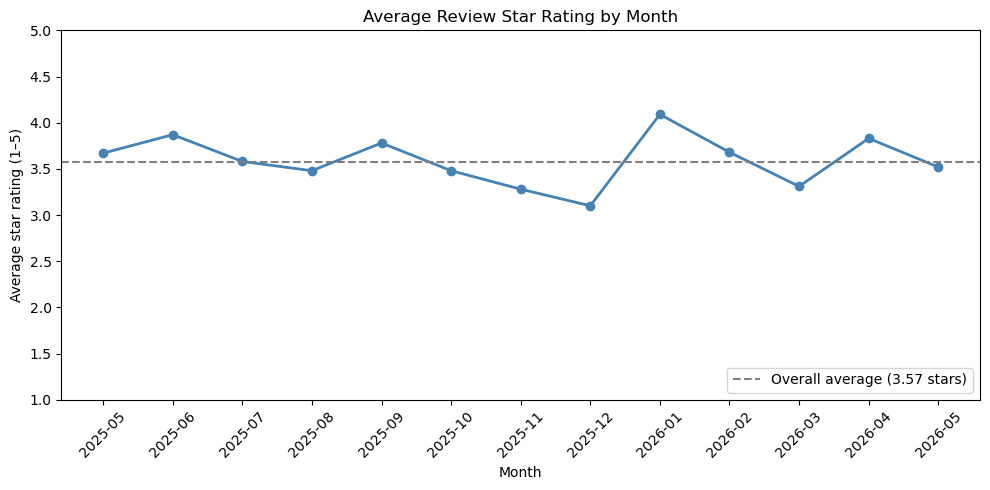

In [35]:
overall = reviews['star_rating'].mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(monthly['month'].astype(str), monthly['avg_rating'],
        marker='o', color='steelblue', linewidth=2)
ax.axhline(overall, linestyle='--', color='grey',
           label=f'Overall average ({overall:.2f} stars)')

ax.set_ylim(1, 5)
ax.set_title('Average Review Star Rating by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Average star rating (1–5)')
ax.legend(loc='lower right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('nlp_review_rating_trend.png', dpi=150)
plt.show()

**Observation: Review star rating over time**
- Customer sentiment is **range-bound**. The monthly average moves between roughly 3.1 and 4.1
  stars around an overall average of 3.57, with no clear upward or downward trend
  (first half 3.58 vs second half 3.56).
- The weakest period was **November–December 2025** (3.28 and 3.10), the only time the rating stayed
  below average for two consecutive months. It is worth investigating what changed then.
- May 2025 has only 3 reviews and should not be over-interpreted.
- Reviews are much more positive than tickets (most reviews are 4–5 stars, while 68% of tickets
  are negative). Tickets capture customers with problems; reviews capture a broader view.
  Using both gives a fuller picture.

## Section D Summary: What customers are saying

- **Tickets are overwhelmingly negative:** 68% negative, 29% neutral, under 2% positive.
- **Billing is the biggest pain point by volume.** Service Failure tickets are the most intensely
  negative (score 0.99), but Billing, with 180 tickets and 100% negative, produces the most negative
  tickets overall. Fixing billing would reduce the most customer frustration.
- **Sentiment only weakly predicts escalation.** Customers who escalated raised slightly more
  negative tickets (0.74 vs 0.70), but the gap is too small to act on alone.
- **Key phrases confirm charges and billing as the main theme** (unexplained charges, duplicate
  transactions, billing disputes), followed by login problems. "Savings account" and "interest rate"
  are frequent, even though the model missed every saver who escalated.
- **Review ratings are range-bound** (about 3.1–4.1 stars, average 3.57), with no clear trend. The
  weakest period was Nov–Dec 2025.
- **Limitation:** only 117 unique ticket texts across 919 tickets (templated data), so the NLP
  findings are indicative, not conclusive.

# Section G: Export for Power BI
Save the model's risk scores and the NLP results as CSV files so Power BI can load them.

In [36]:
# ---- 1. ML output: one row per test customer ----
df_test['risk_score_pct'] = (df_test['y_proba'] * 100).round(1)

df_test['risk_band'] = pd.cut(
    df_test['y_proba'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

export_df = df_test[[
    'customer_id', 'age_band', 'product_type', 'region',
    'primary_channel', 'tenure_months', 'account_value_gbp',
    'previous_complaints', 'risk_score_pct', 'risk_band',
    'y_true', 'y_pred', 'y_pred_030', 'escalated', 'churned', 'nps_score'
]].copy()

export_df.to_csv('meridian_ml_output.csv', index=False)

# ---- 2. NLP output: one row per ticket, with Azure sentiment ----
tickets.to_csv('meridian_nlp_output.csv', index=False)

# ---- 3. Key phrases (noise removed) for Page 3 ----
clean_phrases.to_csv('meridian_key_phrases.csv', index=False)

print(f'ML output:  {len(export_df)} rows')
print(f'NLP output: {len(tickets)} rows')
print(f'Key phrases: {len(clean_phrases)} rows')
print(export_df['risk_band'].value_counts())
print('Flagged at 0.30:', export_df['y_pred_030'].sum())

ML output:  100 rows
NLP output: 919 rows
Key phrases: 15 rows
risk_band
Medium Risk    71
High Risk      23
Low Risk        6
Name: count, dtype: int64
Flagged at 0.30: 94


**Observation: Risk bands**
71 of 100 test customers fall into Medium Risk, 23 High and 6 Low. The model rarely makes a confident
call either way, which is consistent with its weak AUC (0.53). The risk bands should be treated as a
rough prioritisation aid, not a reliable sort.

In [37]:
phrase_lookup.to_csv('ticket_key_phrases_lookup.csv', index=False)

In [38]:
print('Flagged in y_pred:', df_test['y_pred'].sum())
print('Flagged at 0.50:  ', (df_test['y_proba'] >= 0.5).sum())
print('Flagged at 0.30:  ', (df_test['y_proba'] >= 0.3).sum())

Flagged in y_pred: 54
Flagged at 0.50:   54
Flagged at 0.30:   94


# Responsible AI Summary – Complaint Escalation Model

**1. Model purpose**
The model estimates how likely each customer is to escalate a complaint, so the Complaints
team can offer a proactive courtesy call. It must never be used to refuse, price, restrict or
withdraw any product or service, or to make any decision that disadvantages a customer.

**2. Data used**
Four datasets: customer profiles (500 customers), outcomes (escalation, churn, NPS), support tickets
(919) and product reviews (310). The model uses six inputs: tenure, account value, previous
complaints, product type, contact channel and region. Age band was deliberately excluded because age
is a protected characteristic under the Equality Act 2010; it is used only to audit fairness.
Churn, NPS and 12-month complaint count were excluded because they are only known after the event
and would leak the answer. Region and contact channel were kept but flagged as possible
proxies for ethnicity and age.

**3. Performance (in plain English)**
- Ranking ability (AUC 0.53): if we pick one customer who escalated and one who did not, the model
  ranks them correctly only 53% of the time, barely better than a coin toss.
- At the recommended 0.30 threshold, the model flags 94 of 100 customers and catches 25 of the 27
  who escalated (93%).
- Of every 100 customers it flags, only about 27 actually escalate, the same rate as calling
  customers at random.

**4. Bias findings**
At the default 0.50 threshold, performance differs materially by group. Customers aged 36-45 have
the highest escalation rate (41%) but the model catches only 44% of them; customers aged 56-65 are
wrongly flagged 64% of the time; Personal Loan customers who did not escalate were all flagged,
while savers who escalated were all missed. At 0.30 these gaps shrink only because nearly everyone
is flagged. Region accounts for five of the top twelve drivers, and 17 of 23 High Risk customers are
in London or Scotland, yet Power BI's Key Influencers found no significant regional pattern in
actual escalations. These differences are not proportionate or justified by outcomes.

**5. Explainability**
SHAP was used to show which factors drive the model overall and for each individual customer. For
example, customer CUS-0136 escalated but scored only 23%: living in the South East reduced their
risk more than all other factors combined, so they were not offered a call. Every prediction can be
explained to a customer in these terms.

**6. Recommended conditions for deployment**
The model is not ready to deploy. Before any use:
1. A person must review every flag before contact is made; the model may only prioritise, never decide.
2. Region must be tested and removed if it continues to drive outcomes without evidence.
3. A quarterly bias report (recall and false positive rate by age band, product and region) must be
   reviewed by Compliance, and customers must be able to opt out of proactive contact.

## AI Reflection - Module 5 Project

**1. What the model does and does not claim**
The logistic regression model estimates the probability that a customer will escalate a complaint.
Its AUC is 0.53, which means it ranks escalators above non-escalators only slightly better than
chance. I chose a 0.30 threshold because a missed escalation (£800) costs far more than an
unnecessary call (£25), but at that threshold the model flags 94% of customers and is cheaper to
replace with a "contact everyone" policy. The model must never be used to make any decision that
disadvantages a customer, such as refusing or pricing a product.

**2. What the NLP pipeline found**
Using Azure AI Language, 68% of tickets were negative. Billing was the largest source of negativity:
180 tickets, all negative, with "unexplained charge" and "same transaction" the most common key
phrases. Sentiment only weakly predicted escalation (average negative score 0.74 for escalated
customers vs 0.70 for others). Azure also made visible mistakes: a ticket complaining that an issue
promised in 48 hours had taken two weeks was scored as positive, because the model reads words, not
meaning.

**3. What the bias audit revealed**
At the default threshold, the model missed 56% of escalations in the 36-45 group and wrongly flagged
64% of the 56-65 group. Savers who escalated were all missed. SHAP showed region drives many
predictions, 17 of 23 High Risk customers were in London or Scotland, and one customer was missed
mainly because they live in the South East. These differences are not proportionate, and in my
judgement the model is not ready to deploy.

**4. My view on Responsible AI in financial services**

The hardest part of responsible AI is that removing a protected characteristic does not remove the
bias. I was right to exclude age from training, but at the default threshold the model still wrongly
flagged 64% of customers aged 56-65, possibly because tenure or contact channel acted as a proxy for
age. The same happened with region: one customer who escalated was missed mainly because they live in
the South East.

The model also learned generic assumptions from group averages and applied them to individuals. It
treated every Personal Loan customer as likely to complain, so it wrongly flagged those who did not,
and it treated savers as unlikely to complain, so it missed every saver who escalated.

In practice the model would not save Meridian any money. At the 0.30 threshold it flagged 94 of the
100 test customers and still missed 2 of the 27 who escalated. Calling all 100 customers would cost
less and miss no one.


With more data, I would retrain the model with age band still excluded and tenure and region also
removed, then compare both the fairness results and the accuracy against the current model, to see
whether a fairer model is still useful to the business.